# Qwen-only MaskClustering for room0

This notebook takes precomputed Qwen pair scores and uses them as the graph edges for MaskClustering.

Run this notebook in the `maskclustering` environment. Qwen inference itself should already be finished and saved as a CSV.

## 1. Setup

In [1]:
from pathlib import Path
from types import SimpleNamespace
import json
import os
import shutil
import subprocess
import sys

import cv2
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "MaskClustering").is_dir() and (path / "Project").is_dir():
            return path
    raise RuntimeError("Could not find repository root")


REPO_ROOT = find_repo_root()
MASKCLUSTERING_ROOT = REPO_ROOT / "MaskClustering"
MILESTONE_3 = REPO_ROOT / "Project" / "Milestone_3"
OUTPUT_ROOT = MILESTONE_3 / "data" / "qwen_clustering"

if str(MASKCLUSTERING_ROOT) not in sys.path:
    sys.path.insert(0, str(MASKCLUSTERING_ROOT))

# MaskClustering uses relative paths such as ./data/replica/..., so run from its root.
os.chdir(MASKCLUSTERING_ROOT)

from graph.construction import mask_graph_construction
from graph.iterative_clustering import cluster_into_new_nodes
from utils.config import get_dataset
from utils.post_process import post_process

SCENE = "room0"
CONFIG_NAME = "replica"
QWEN_THRESHOLD = 0.50

SCORES_CSV = MILESTONE_3 / "data" / "qwen_scores" / f"{SCENE}_qwen_scores.csv"
RGB_DIR = REPO_ROOT / "data" / "replica" / SCENE / "color"
MASK_DIR = REPO_ROOT / "data" / "replica" / SCENE / "output" / "mask"
GT_DIR = REPO_ROOT / "data" / "replica" / "ground_truth"

print("Repo root          :", REPO_ROOT)
print("MaskClustering root:", MASKCLUSTERING_ROOT)
print("Scores CSV         :", SCORES_CSV)
print("CUDA available     :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU                :", torch.cuda.get_device_name(0))

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Repo root          : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping
MaskClustering root: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/MaskClustering
Scores CSV         : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone_3/data/qwen_scores/room0_qwen_scores.csv
CUDA available     : True
GPU                : NVIDIA GeForce RTX 3090


## 2. Load Qwen scores

In [2]:
if not SCORES_CSV.exists():
    raise FileNotFoundError(
        f"Qwen score CSV not found: {SCORES_CSV}\n"
        "Run score_qwen_candidates.py first."
    )

scores = pd.read_csv(SCORES_CSV)
print("Rows:", len(scores))
print("Columns:", list(scores.columns))

display(scores.head(10))

if "qwen_reasoning" in scores.columns:
    parse_errors = (scores["qwen_reasoning"] == "<parse error>").sum()
    print("Parse errors:", parse_errors)

if "same_instance_label" in scores.columns:
    print("GT label counts:")
    display(scores["same_instance_label"].value_counts(dropna=False))

print("Qwen decision counts:")
display(scores["qwen_decision"].value_counts(dropna=False))

Rows: 1245
Columns: ['scene', 'frame_a', 'mask_a', 'frame_b', 'mask_b', 'global_mask_idx_a', 'global_mask_idx_b', 'points_a', 'points_b', 'points_intersection', 'depth_iou', 'overlap_a_to_b', 'overlap_b_to_a', 'num_observers', 'num_supporters', 'view_consensus_score', 'gt_instance_a', 'gt_instance_b', 'same_instance_label', 'qwen_decision', 'qwen_confidence', 'qwen_reasoning', 'qwen_same_instance_score']


,scene,frame_a,mask_a,frame_b,mask_b,global_mask_idx_a,global_mask_idx_b,points_a,points_b,points_intersection,...,num_observers,num_supporters,view_consensus_score,gt_instance_a,gt_instance_b,same_instance_label,qwen_decision,qwen_confidence,qwen_reasoning,qwen_same_instance_score
0,room0,0,2,20,3,1,31,4291,3880,3010,...,5.0,5.0,1.000000,97061,97061,1,0,0.00,Region A and Region B are not the same physica...,0.00
1,room0,0,2,30,2,1,45,4291,3790,3602,...,5.0,5.0,1.000000,97061,97061,1,0,0.00,The two regions are not the same physical obje...,0.00
2,room0,0,2,30,3,1,46,4291,9492,812,...,5.0,0.0,0.000000,97061,37036,0,1,0.95,"Both regions outline the same door, which is a...",0.95
3,room0,0,2,40,1,1,62,4291,4509,4034,...,5.0,5.0,1.000000,97061,97061,1,1,0.99,"The two regions are identical in appearance, b...",0.99
4,room0,0,2,50,2,1,78,4291,5640,4175,...,5.0,5.0,1.000000,97061,97061,1,1,0.99,"The two regions are identical in shape, size, ...",0.99
5,room0,0,3,10,11,2,27,41369,27606,24519,...,9.0,9.0,1.000000,40025,40025,1,0,0.00,Region A and Region B are not the same physica...,0.00
6,room0,0,3,20,9,2,37,41369,40289,25470,...,10.0,10.0,1.000000,40025,40025,1,0,0.00,Region A and Region B do not belong to the sam...,0.00
7,room0,0,3,20,14,2,42,41369,11549,2561,...,7.0,4.0,0.571429,40025,98060,0,0,0.00,Region A includes the ottomans and a portion o...,0.00
8,room0,0,3,30,11,2,54,41369,35339,22429,...,10.0,10.0,1.000000,40025,40025,1,0,0.00,Region A and Region B are not the same physica...,0.00
9,room0,0,3,30,13,2,56,41369,6377,2307,...,6.0,3.0,0.500000,40025,98060,0,0,0.00,Region A includes the ottomans and part of the...,0.00


Parse errors: 0
GT label counts:


same_instance_label
1    1083
0     162
Name: count, dtype: int64

Qwen decision counts:


qwen_decision
0    899
1    346
Name: count, dtype: int64

## 3. Inspect Qwen score distribution

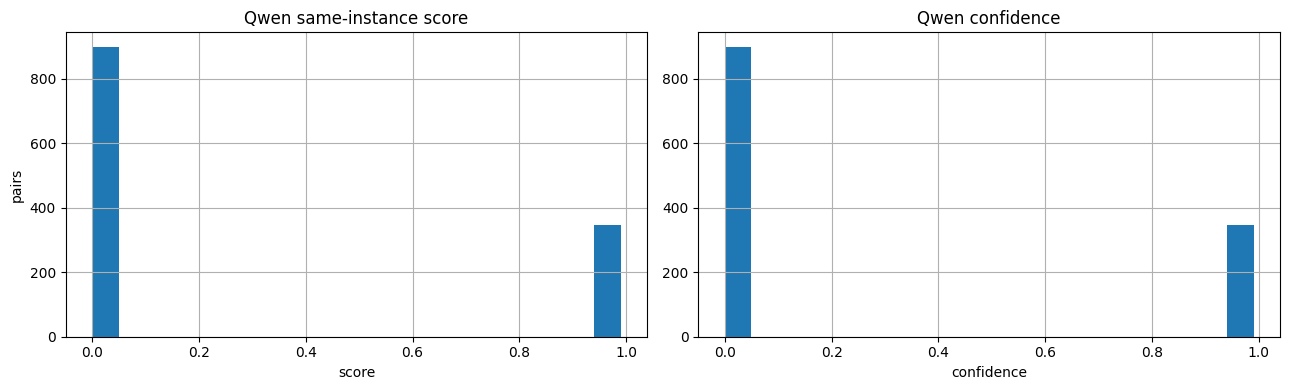

Mean Qwen score by GT label:


,count,mean,std,min,25%,50%,75%,max
same_instance_label,,,,,,,,
0,162.0,0.170062,0.365324,0.0,0.0,0.0,0.00,0.95
1,1083.0,0.278476,0.433104,0.0,0.0,0.0,0.95,0.99


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

scores["qwen_same_instance_score"].hist(bins=20, ax=axes[0])
axes[0].set_title("Qwen same-instance score")
axes[0].set_xlabel("score")
axes[0].set_ylabel("pairs")

scores["qwen_confidence"].hist(bins=20, ax=axes[1])
axes[1].set_title("Qwen confidence")
axes[1].set_xlabel("confidence")

plt.tight_layout()
plt.show()

if "same_instance_label" in scores.columns:
    labeled = scores[scores["same_instance_label"].isin([0, 1])].copy()
    if len(labeled):
        print("Mean Qwen score by GT label:")
        display(labeled.groupby("same_instance_label")["qwen_same_instance_score"].describe())

## 4. False positive / false negative inspection

In [4]:
if "same_instance_label" in scores.columns:
    labeled = scores[scores["same_instance_label"].isin([0, 1])].copy()
    false_negatives = labeled[(labeled["same_instance_label"] == 1) & (labeled["qwen_decision"] == 0)]
    false_positives = labeled[(labeled["same_instance_label"] == 0) & (labeled["qwen_decision"] == 1)]

    print("False negatives:", len(false_negatives))
    print("False positives:", len(false_positives))

    display(false_negatives.head(10))
    display(false_positives.head(10))
else:
    print("No same_instance_label column available.")

False negatives: 766
False positives: 29


,scene,frame_a,mask_a,frame_b,mask_b,global_mask_idx_a,global_mask_idx_b,points_a,points_b,points_intersection,...,num_observers,num_supporters,view_consensus_score,gt_instance_a,gt_instance_b,same_instance_label,qwen_decision,qwen_confidence,qwen_reasoning,qwen_same_instance_score
0,room0,0,2,20,3,1,31,4291,3880,3010,...,5.0,5.0,1.0,97061,97061,1,0,0.0,Region A and Region B are not the same physica...,0.0
1,room0,0,2,30,2,1,45,4291,3790,3602,...,5.0,5.0,1.0,97061,97061,1,0,0.0,The two regions are not the same physical obje...,0.0
5,room0,0,3,10,11,2,27,41369,27606,24519,...,9.0,9.0,1.0,40025,40025,1,0,0.0,Region A and Region B are not the same physica...,0.0
6,room0,0,3,20,9,2,37,41369,40289,25470,...,10.0,10.0,1.0,40025,40025,1,0,0.0,Region A and Region B do not belong to the sam...,0.0
8,room0,0,3,30,11,2,54,41369,35339,22429,...,10.0,10.0,1.0,40025,40025,1,0,0.0,Region A and Region B are not the same physica...,0.0
10,room0,0,3,40,13,2,74,41369,31961,28329,...,9.0,9.0,1.0,40025,40025,1,0,0.0,The two regions are not the same physical obje...,0.0
11,room0,0,3,50,9,2,85,41369,25738,22171,...,8.0,8.0,1.0,40025,40025,1,0,0.0,The two regions are not the same physical obje...,0.0
12,room0,0,3,60,7,2,99,41369,8729,5090,...,8.0,8.0,1.0,40025,40025,1,0,0.0,Region A and Region B are not the same physica...,0.0
13,room0,0,3,180,14,2,351,41369,35383,5612,...,8.0,8.0,1.0,40025,40025,1,0,0.0,Region A and Region B do not belong to the sam...,0.0
14,room0,0,3,190,2,2,358,41369,34030,12655,...,8.0,8.0,1.0,40025,40025,1,0,0.0,Region A and Region B are not the same physica...,0.0


,scene,frame_a,mask_a,frame_b,mask_b,global_mask_idx_a,global_mask_idx_b,points_a,points_b,points_intersection,...,num_observers,num_supporters,view_consensus_score,gt_instance_a,gt_instance_b,same_instance_label,qwen_decision,qwen_confidence,qwen_reasoning,qwen_same_instance_score
2,room0,0,2,30,3,1,46,4291,9492,812,...,5.0,0.0,0.000000,97061,37036,0,1,0.95,"Both regions outline the same door, which is a...",0.95
63,room0,0,14,50,18,13,93,50145,47163,36404,...,9.0,9.0,1.000000,93048,93033,0,1,0.95,Region A and Region B are both parts of the sa...,0.95
117,room0,20,2,30,10,30,53,7633,16124,7620,...,4.0,4.0,1.000000,12050,12030,0,1,0.95,Both regions depict the same window with blind...,0.95
166,room0,20,14,190,2,42,358,11549,34030,3310,...,6.0,4.0,0.666667,98060,40025,0,1,0.95,Region A and Region B both depict the same are...,0.95
353,room0,70,5,100,13,114,187,27698,69528,26560,...,11.0,11.0,1.000000,12015,12019,0,1,0.95,Region A and Region B both depict the same phy...,0.95
354,room0,70,5,110,7,114,204,27698,71128,26659,...,11.0,11.0,1.000000,12015,12022,0,1,0.95,Region A and Region B both outline the same se...,0.95
356,room0,70,5,130,3,114,241,27698,35566,27140,...,11.0,11.0,1.000000,12015,12019,0,1,0.95,Region A and Region B are both the same physic...,0.95
357,room0,70,5,140,3,114,253,27698,39958,26718,...,11.0,11.0,1.000000,12015,12019,0,1,0.95,Region A and Region B are both the same physic...,0.95
459,room0,80,3,90,17,133,171,379,698,94,...,3.0,0.0,0.000000,13059,65043,0,1,0.95,Region A and Region B both outline the same ph...,0.95
461,room0,80,3,100,17,133,191,379,756,82,...,3.0,0.0,0.000000,13059,65043,0,1,0.95,Region A and Region B both outline the same co...,0.95


## 5. Visualize selected Qwen pairs

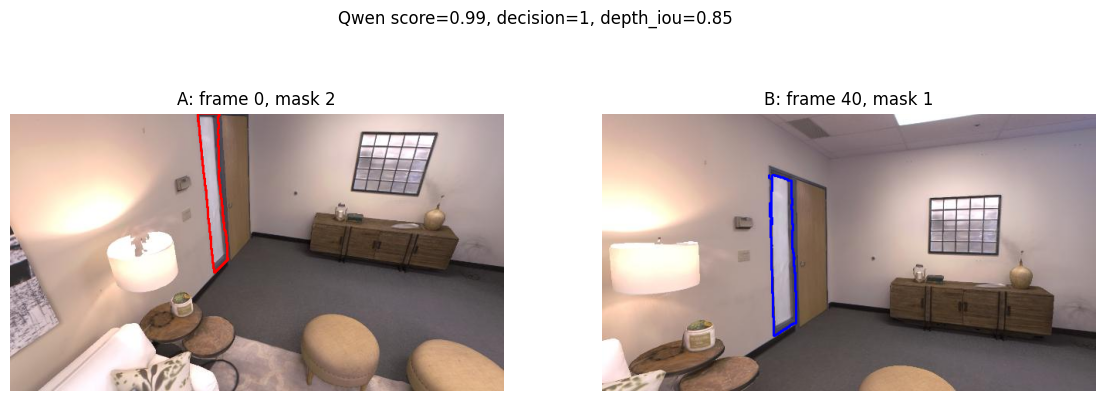

The two regions are identical in appearance, both highlighting the same door with a vertical glass panel.


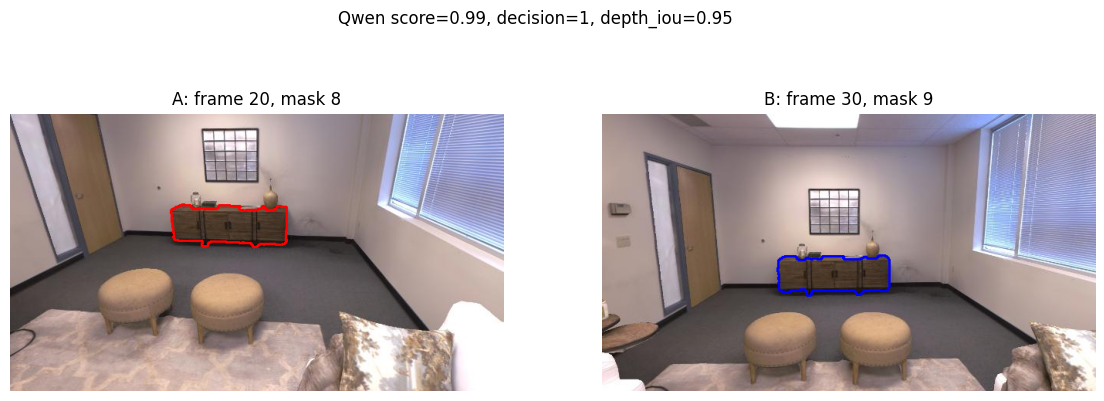

The two regions are the same physical object, as they both outline the identical wooden console table with the same features, including the drawers, the vase, and the small decorative items.


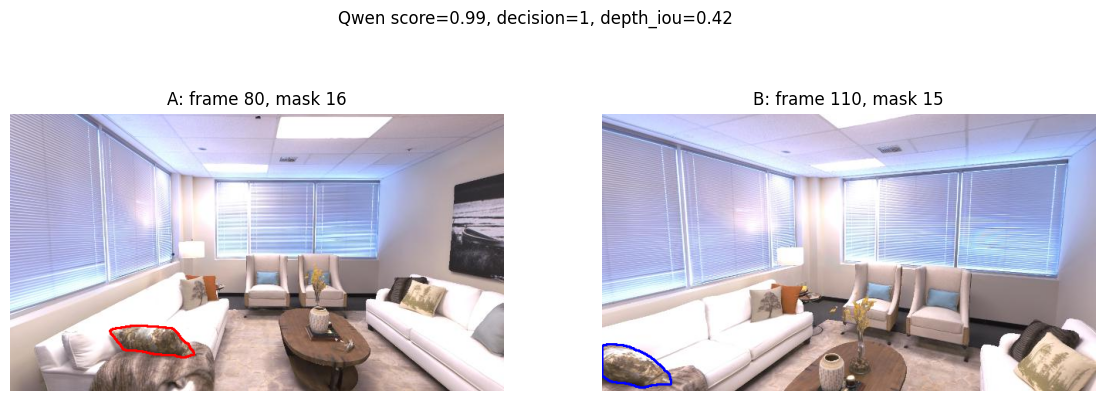

The two regions are identical in appearance and location, both highlighting the same decorative pillow on the same white sofa.


In [5]:
def load_rgb(frame_id):
    path = RGB_DIR / f"{int(frame_id)}.jpg"
    bgr = cv2.imread(str(path))
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def load_mask(frame_id):
    path = MASK_DIR / f"{int(frame_id)}.png"
    mask = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if mask is None:
        raise FileNotFoundError(path)
    return mask


def draw_outline(rgb, mask_map, mask_id, color, thickness=2):
    out = rgb.copy()
    binary = (mask_map == int(mask_id)).astype(np.uint8)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cv2.drawContours(out, contours, -1, color, thickness)
    return out


def show_pair(row):
    rgb_a = load_rgb(row.frame_a)
    rgb_b = load_rgb(row.frame_b)
    mask_a_map = load_mask(row.frame_a)
    mask_b_map = load_mask(row.frame_b)

    view_a = draw_outline(rgb_a, mask_a_map, row.mask_a, color=(255, 0, 0), thickness=2)
    view_b = draw_outline(rgb_b, mask_b_map, row.mask_b, color=(0, 0, 255), thickness=2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    title = (
        f"Qwen score={row.qwen_same_instance_score:.2f}, "
        f"decision={int(row.qwen_decision)}, "
        f"depth_iou={row.depth_iou:.2f}"
    )
    fig.suptitle(title)
    axes[0].imshow(view_a)
    axes[0].set_title(f"A: frame {int(row.frame_a)}, mask {int(row.mask_a)}")
    axes[0].axis("off")
    axes[1].imshow(view_b)
    axes[1].set_title(f"B: frame {int(row.frame_b)}, mask {int(row.mask_b)}")
    axes[1].axis("off")
    plt.show()
    print(row.qwen_reasoning)


# Change this selection freely.
example_rows = scores.sort_values("qwen_same_instance_score", ascending=False).head(3)
for _, row in example_rows.iterrows():
    show_pair(row)

## 6. Build MaskClustering inputs

In [6]:
def load_maskclustering_args(config_name, scene, output_name, debug=True):
    config_path = MASKCLUSTERING_ROOT / "configs" / f"{config_name}.json"
    config = json.loads(config_path.read_text())
    config.update(
        {
            "seq_name": scene,
            "seq_name_list": scene,
            "config": output_name,
            "debug": debug,
        }
    )
    return SimpleNamespace(**config)


OUTPUT_NAME = f"qwen_{CONFIG_NAME}_thr_{QWEN_THRESHOLD:.2f}"
args = load_maskclustering_args(CONFIG_NAME, SCENE, OUTPUT_NAME, debug=True)

dataset = get_dataset(args)
scene_points = dataset.get_scene_points()
frame_list = dataset.get_frame_list(args.step)

print("Output name:", OUTPUT_NAME)
print("Scene points:", scene_points.shape)
print("Frames:", len(frame_list), frame_list[:10])

with torch.no_grad():
    nodes, observer_num_thresholds, mask_point_clouds, point_frame_matrix = mask_graph_construction(
        args,
        scene_points,
        frame_list,
        dataset,
    )

print("Initial valid nodes:", len(nodes))

Output name: qwen_replica_thr_0.50
Scene points: (954492, 3)
Frames: 20 [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
start building point in mask matrix


100%|███████████████████████████████████████████████████████████████████████████████| 20/20 [00:06<00:00,  3.13it/s]


start processing masks


100%|████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 586.53it/s]


Initial valid nodes: 353


## 7. Build Qwen-only graph and clusters

Qwen threshold: 0.5
Qwen graph nodes: 353
Qwen graph edges: 346
Qwen clusters: 166
Clusters with >=2 masks: 43


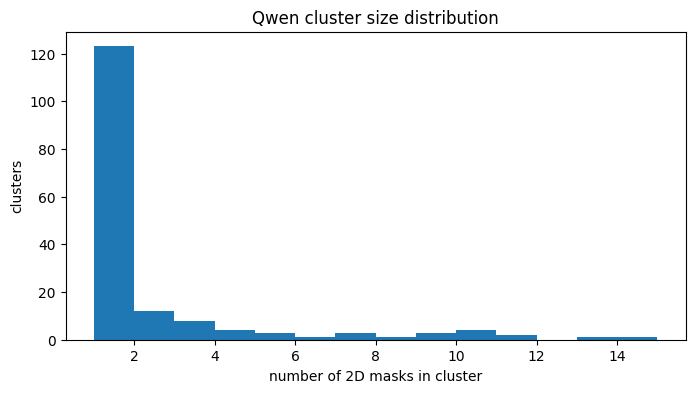

In [7]:
def build_qwen_graph(nodes, scores_df, threshold):
    graph = nx.Graph()
    graph.add_nodes_from(range(len(nodes)))

    node_by_mask = {}
    for node_idx, node in enumerate(nodes):
        if len(node.mask_list) == 1:
            frame_id, mask_id = node.mask_list[0]
            node_by_mask[(int(frame_id), int(mask_id))] = node_idx

    edges = []
    for _, row in scores_df.iterrows():
        score = float(row["qwen_same_instance_score"])
        if score < threshold:
            continue
        key_a = (int(row["frame_a"]), int(row["mask_a"]))
        key_b = (int(row["frame_b"]), int(row["mask_b"]))
        node_a = node_by_mask.get(key_a)
        node_b = node_by_mask.get(key_b)
        if node_a is None or node_b is None or node_a == node_b:
            continue
        graph.add_edge(node_a, node_b, weight=score)
        edges.append((node_a, node_b, score))

    return graph, edges


qwen_graph, qwen_edges = build_qwen_graph(nodes, scores, QWEN_THRESHOLD)
qwen_clusters = cluster_into_new_nodes(1, nodes, qwen_graph)

cluster_sizes = [len(node.mask_list) for node in qwen_clusters]
print("Qwen threshold:", QWEN_THRESHOLD)
print("Qwen graph nodes:", qwen_graph.number_of_nodes())
print("Qwen graph edges:", qwen_graph.number_of_edges())
print("Qwen clusters:", len(qwen_clusters))
print("Clusters with >=2 masks:", sum(size >= 2 for size in cluster_sizes))

plt.figure(figsize=(8, 4))
plt.hist(cluster_sizes, bins=range(1, max(cluster_sizes) + 2))
plt.title("Qwen cluster size distribution")
plt.xlabel("number of 2D masks in cluster")
plt.ylabel("clusters")
plt.show()

## 8. Visualize Qwen clusters

First clusters with >=2 masks: [0, 5, 6, 8, 9, 11, 12, 13, 14, 22]


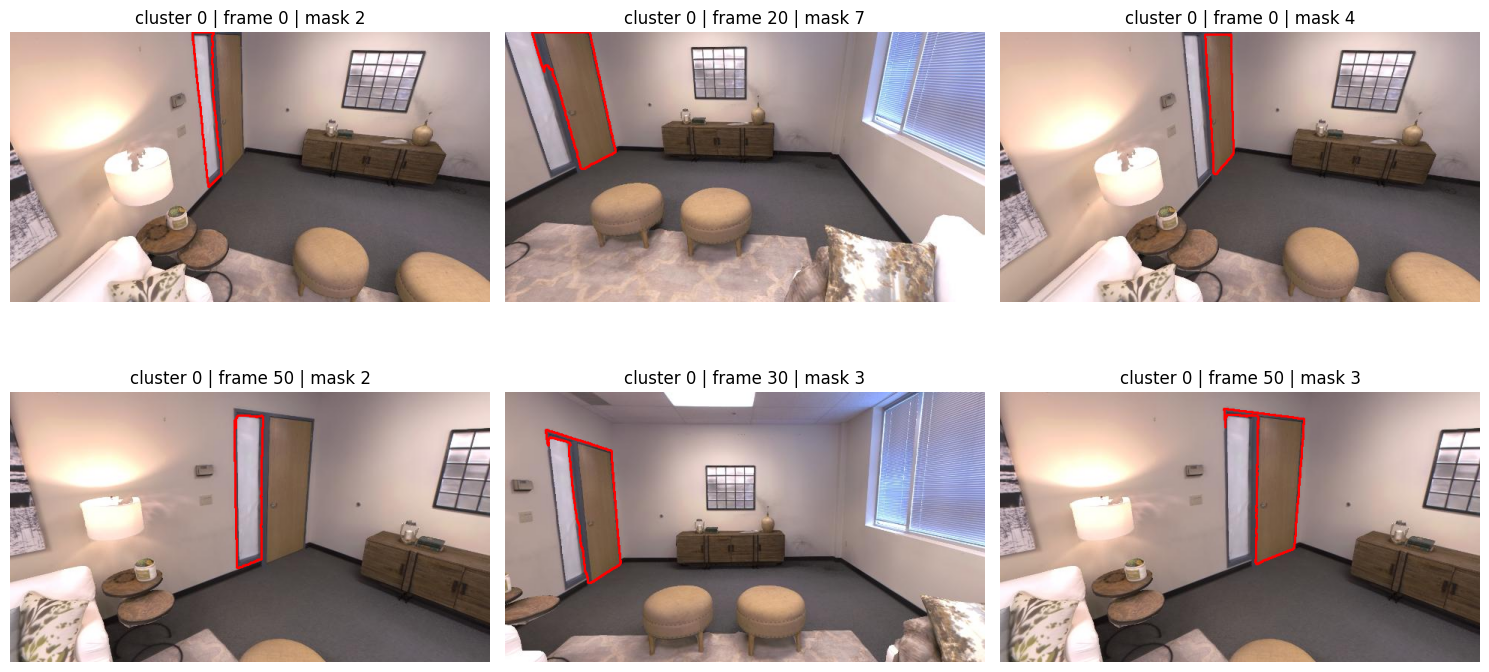

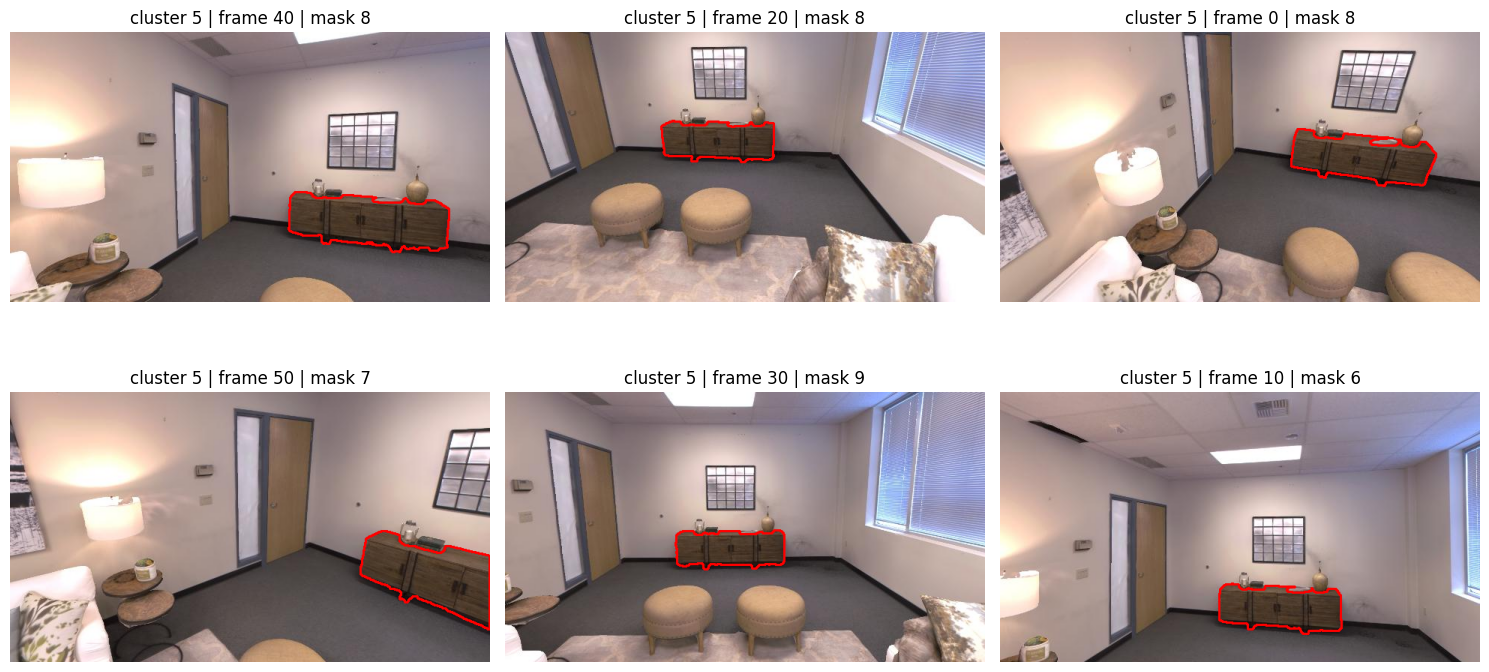

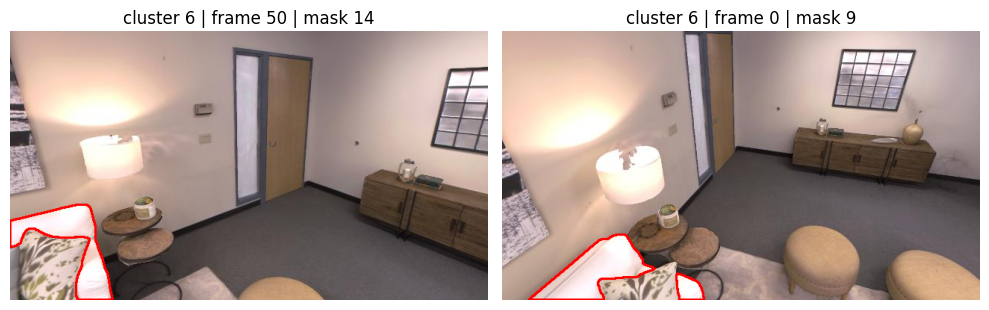

In [8]:
def show_cluster(cluster_id, max_masks=6):
    node = qwen_clusters[int(cluster_id)]
    mask_list = node.mask_list[:max_masks]
    if not mask_list:
        print("Empty cluster")
        return

    cols = min(3, len(mask_list))
    rows = int(np.ceil(len(mask_list) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (frame_id, mask_id) in zip(axes, mask_list):
        rgb = load_rgb(frame_id)
        mask_map = load_mask(frame_id)
        view = draw_outline(rgb, mask_map, mask_id, color=(255, 0, 0), thickness=2)
        ax.imshow(view)
        ax.set_title(f"cluster {cluster_id} | frame {frame_id} | mask {mask_id}")
        ax.axis("off")

    for ax in axes[len(mask_list):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


large_cluster_ids = [i for i, size in enumerate(cluster_sizes) if size >= 2]
print("First clusters with >=2 masks:", large_cluster_ids[:10])

for cluster_id in large_cluster_ids[:3]:
    show_cluster(cluster_id, max_masks=6)

## 9. Export Qwen prediction npz

In [9]:
with torch.no_grad():
    post_process(
        dataset,
        qwen_clusters,
        mask_point_clouds,
        scene_points,
        point_frame_matrix,
        frame_list,
        args,
    )

pred_path = REPO_ROOT / "data" / "prediction" / f"{OUTPUT_NAME}_class_agnostic" / f"{SCENE}.npz"
if not pred_path.exists():
    raise FileNotFoundError(pred_path)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
copied_pred_path = OUTPUT_ROOT / f"{SCENE}_qwen_thr_{QWEN_THRESHOLD:.2f}.npz"
shutil.copy2(pred_path, copied_pred_path)

print("Prediction npz:", pred_path)
print("Copied to     :", copied_pred_path)

start exporting
Prediction npz: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/prediction/qwen_replica_thr_0.50_class_agnostic/room0.npz
Copied to     : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone_3/data/qwen_clustering/room0_qwen_thr_0.50.npz


## 10. Compute class-agnostic AP

In [11]:
eval_output = OUTPUT_ROOT / f"{SCENE}_qwen_thr_{QWEN_THRESHOLD:.2f}_ap_class_agnostic.txt"
cmd = [
    sys.executable,
    "-m",
    "evaluation.evaluate",
    "--pred_path",
    str(REPO_ROOT / "data" / "prediction" / f"{OUTPUT_NAME}_class_agnostic"),
    "--gt_path",
    str(GT_DIR),
    "--dataset",
    CONFIG_NAME,
    "--no_class",
    "--output_file",
    str(eval_output),
]

env = os.environ.copy()
env["PYTHONPATH"] = str(MASKCLUSTERING_ROOT) + os.pathsep + env.get("PYTHONPATH", "")

print("Running:", " ".join(cmd))
result = subprocess.run(cmd, cwd=MASKCLUSTERING_ROOT, env=env, text=True, capture_output=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f"Evaluation failed with exit code {result.returncode}")

print("Saved AP results to:", eval_output)
print(eval_output.read_text())

Running: /rhome/flowis153/miniconda3/envs/maskclustering/bin/python -m evaluation.evaluate --pred_path /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/prediction/qwen_replica_thr_0.50_class_agnostic --gt_path /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica/ground_truth --dataset replica --no_class --output_file /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone_3/data/qwen_clustering/room0_qwen_thr_0.50_ap_class_agnostic.txt
start evaluating: qwen_replica_thr_0.50_class_agnostic
evaluating 1 scans...

scans processed: 1
################################################################
what           :             AP         AP_50%         AP_25%
################################################################
basket         :          0.048          0.100          0.259
----------------------------------------------------------------
average        :          0.048          0.100          0.259

save results to /rhome/flowis153

## 11. Optional threshold sweep

Run this only after the single-threshold version works. It repeats clustering, export, and AP for several Qwen thresholds.

In [ ]:
RUN_THRESHOLD_SWEEP = False
THRESHOLDS = [0.3, 0.5, 0.7, 0.9]

sweep_results = []

if RUN_THRESHOLD_SWEEP:
    for threshold in THRESHOLDS:
        output_name = f"qwen_{CONFIG_NAME}_thr_{threshold:.2f}"
        sweep_args = load_maskclustering_args(CONFIG_NAME, SCENE, output_name, debug=False)

        graph, _ = build_qwen_graph(nodes, scores, threshold)
        clusters = cluster_into_new_nodes(1, nodes, graph)
        post_process(dataset, clusters, mask_point_clouds, scene_points, point_frame_matrix, frame_list, sweep_args)

        eval_output = OUTPUT_ROOT / f"{SCENE}_qwen_thr_{threshold:.2f}_ap.txt"
        cmd = [
            sys.executable,
            "-m",
            "evaluation.evaluate",
            "--pred_path",
            str(REPO_ROOT / "data" / "prediction" / f"{output_name}_class_agnostic"),
            "--gt_path",
            str(GT_DIR),
            "--dataset",
            CONFIG_NAME,
            "--no_class",
            "--output_file",
            str(eval_output),
        ]
        result = subprocess.run(cmd, cwd=MASKCLUSTERING_ROOT, env=env, text=True, capture_output=True)
        if result.returncode != 0:
            print(result.stdout)
            print(result.stderr)
            raise RuntimeError(f"Evaluation failed for threshold {threshold}")

        print(f"threshold {threshold:.2f}")
        print(result.stdout)
        sweep_results.append({"threshold": threshold, "ap_file": str(eval_output)})

display(pd.DataFrame(sweep_results))